In [1]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pyulog import ULog

plt.style.use('dark_background')
LOG_PATH = '../data/logs/log_0_2026-6-6-22-21-20.ulg'

ulog = ULog(LOG_PATH)
pos = ulog.get_dataset('vehicle_local_position')
t = pos.data['timestamp']
duration = (t[-1] - t[0]) / 1e6

print(f"✅ Log cargado")
print(f"   Duración: {duration:.1f}s ({duration/60:.1f} min)")
print(f"   Topics: {len(ulog.data_list)}")

✅ Log cargado
   Duración: 334.2s (5.6 min)
   Topics: 81


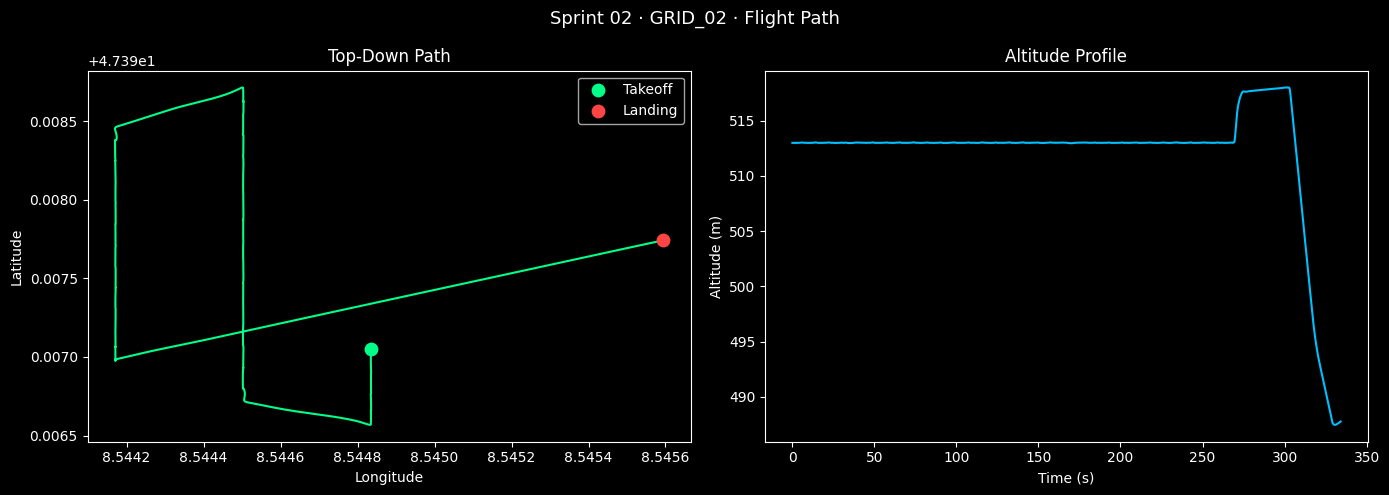

✅ Flight path generado


In [2]:
# ── Trayectoria + Altitud ─────────────────────────────────
gps = ulog.get_dataset('vehicle_global_position')
t_gps = (gps.data['timestamp'] - gps.data['timestamp'][0]) / 1e6
lat = gps.data['lat']
lon = gps.data['lon']
alt = gps.data['alt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sprint 02 · GRID_02 · Flight Path', fontsize=13, color='white')

axes[0].plot(lon, lat, color='#00FF88', linewidth=1.5)
axes[0].scatter(lon[0], lat[0], color='#00FF88', s=80, zorder=5, label='Takeoff')
axes[0].scatter(lon[-1], lat[-1], color='#FF4444', s=80, zorder=5, label='Landing')
axes[0].set_title('Top-Down Path', color='white')
axes[0].set_xlabel('Longitude', color='white')
axes[0].set_ylabel('Latitude', color='white')
axes[0].legend()
axes[0].tick_params(colors='white')

axes[1].plot(t_gps, alt, color='#00BFFF', linewidth=1.5)
axes[1].set_title('Altitude Profile', color='white')
axes[1].set_xlabel('Time (s)', color='white')
axes[1].set_ylabel('Altitude (m)', color='white')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.savefig('../data/flight_path_grid02.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Flight path generado")

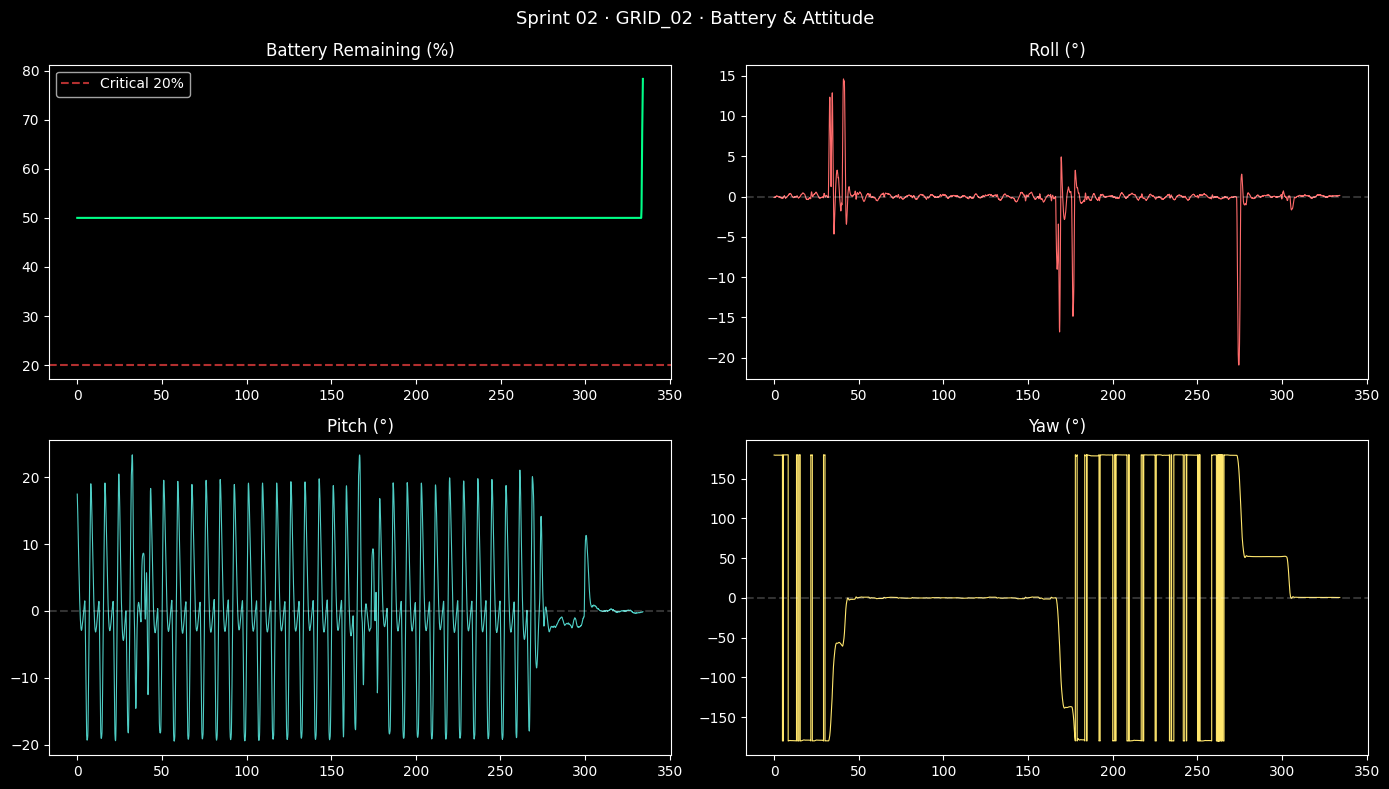

✅ Battery & Attitude generado


In [4]:
# ── Battery + Attitude ────────────────────────────────────
bat = ulog.get_dataset('battery_status')
t_bat = (bat.data['timestamp'] - bat.data['timestamp'][0]) / 1e6
remaining = bat.data['remaining'] * 100

att = ulog.get_dataset('vehicle_attitude')
t_att = (att.data['timestamp'] - att.data['timestamp'][0]) / 1e6
q0,q1,q2,q3 = att.data['q[0]'],att.data['q[1]'],att.data['q[2]'],att.data['q[3]']
roll  = np.degrees(np.arctan2(2*(q0*q1+q2*q3),1-2*(q1**2+q2**2)))
pitch = np.degrees(np.arcsin(np.clip(2*(q0*q2-q3*q1),-1,1)))
yaw   = np.degrees(np.arctan2(2*(q0*q3+q1*q2),1-2*(q2**2+q3**2)))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Sprint 02 · GRID_02 · Battery & Attitude', fontsize=13, color='white')

axes[0,0].plot(t_bat, remaining, color='#00FF88', linewidth=1.5)
axes[0,0].axhline(y=20, color='#FF4444', linestyle='--', alpha=0.7, label='Critical 20%')
axes[0,0].set_title('Battery Remaining (%)', color='white')
axes[0,0].tick_params(colors='white')
axes[0,0].legend()

for ax, data, label, color in zip(
    [axes[0,1], axes[1,0], axes[1,1]],
    [roll, pitch, yaw],
    ['Roll (°)', 'Pitch (°)', 'Yaw (°)'],
    ['#FF6B6B', '#4ECDC4', '#FFE66D']
):
    ax.plot(t_att, data, color=color, linewidth=0.8)
    ax.set_title(label, color='white')
    ax.tick_params(colors='white')
    ax.axhline(y=0, color='white', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.savefig('../data/attitude_grid02.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Battery & Attitude generado")

In [6]:
# ── Mission Summary ───────────────────────────────────────
max_alt = alt.max()
min_alt = alt.min()
total_distance = np.sum(np.sqrt(np.diff(lat)**2 + np.diff(lon)**2)) * 111139
roll_max = np.abs(roll).max()
pitch_max = np.abs(pitch).max()

summary = f"""
╔══════════════════════════════════════════╗
║     SPRINT 02 · GRID_02 · SUMMARY        ║
╠══════════════════════════════════════════╣
║  Duration        : {duration:.1f}s ({duration/60:.1f} min)      
║  Max Altitude    : {max_alt:.1f}m             
║  Min Altitude    : {min_alt:.1f}m             
║  Est. Distance   : {total_distance:.1f}m          
║  Max Roll        : {roll_max:.1f}°            
║  Max Pitch       : {pitch_max:.1f}°            
║  Battery End     : {remaining[-1]:.1f}%           
║  Mission Items   : 42                    
║  Dropouts        : 0                     
║  PX4 Version     : v1.18.0 SITL          
╚══════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════╗
║     SPRINT 02 · GRID_02 · SUMMARY        ║
╠══════════════════════════════════════════╣
║  Duration        : 334.2s (5.6 min)      
║  Max Altitude    : 518.0m             
║  Min Altitude    : 487.5m             
║  Est. Distance   : 714.4m          
║  Max Roll        : 20.9°            
║  Max Pitch       : 23.4°            
║  Battery End     : 78.3%           
║  Mission Items   : 42                    
║  Dropouts        : 0                     
║  PX4 Version     : v1.18.0 SITL          
╚══════════════════════════════════════════╝

